In [12]:
import subprocess
subprocess.run(["python", "../data/generate_data.py"])

CompletedProcess(args=['python', '../data/generate_data.py'], returncode=0)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
# Path setup
data_path = Path("../data/dataset.csv").resolve()

# Load dataset
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print(df.head())

Shape: (1100, 5)
       width    spacing    x_coord    y_coord  label
0  41.968918  55.415902  -5.577101  10.044452    0.0
1  49.230640  45.360199   8.829402 -10.758954    0.0
2  57.787601  41.036929  -1.923631   8.367453    0.0
3  48.634041  50.051837 -13.665386   0.405630    0.0
4  48.305596  47.094536  10.231907  -2.229131    0.0


In [3]:
# Features and target
X = df.drop(columns=["label"])
y = df["label"]

print(X.columns)
print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Index(['width', 'spacing', 'x_coord', 'y_coord'], dtype='str')
Feature shape: (1100, 4)
Target distribution:
 label
0.0    1000
1.0     100
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (880, 4)
Test size: (220, 4)


In [5]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [6]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # for ROC-AUC

In [7]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000


Saved → C:\Users\nkris\OneDrive\Desktop\Hotspot_Detection\results\rf_confusion_matrix.png


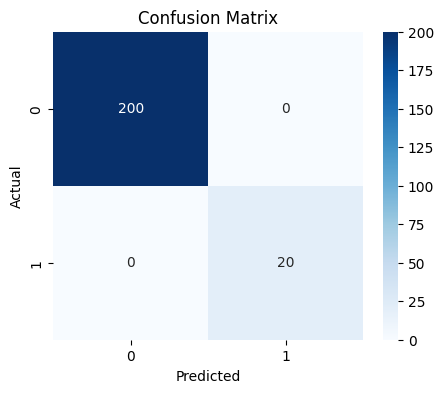

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save figure
results_path = Path("../results").resolve()
results_path.mkdir(exist_ok=True)
cm_path = results_path / "rf_confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches='tight')

print("Saved →", cm_path)
plt.show()

ROC-AUC: 1.0000
Saved → C:\Users\nkris\OneDrive\Desktop\Hotspot_Detection\results\rf_roc_curve.png


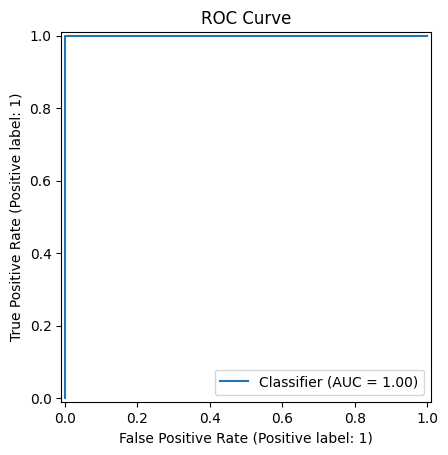

In [9]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.4f}")

fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
plt.title("ROC Curve")

# Save figure
roc_path = results_path / "rf_roc_curve.png"
plt.savefig(roc_path, dpi=150, bbox_inches='tight')

print("Saved →", roc_path)
plt.show()

Saved → C:\Users\nkris\OneDrive\Desktop\Hotspot_Detection\results\rf_feature_importance.png


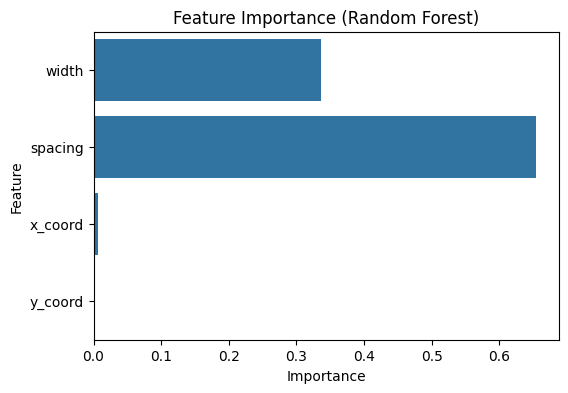

In [10]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

# Save figure
fi_path = results_path / "rf_feature_importance.png"
plt.savefig(fi_path, dpi=150, bbox_inches='tight')

print("Saved →", fi_path)
plt.show()

In [11]:
results_path = Path("../results").resolve()
results_path.mkdir(exist_ok=True)

with open(results_path / "rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Random Forest model saved → results/rf_model.pkl ✅")

Random Forest model saved → results/rf_model.pkl ✅
